In [64]:
# Import Required Libraries
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import Whitebox
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.set_verbose_mode(False)

print("✓ All libraries imported successfully")
print(f"✓ Whitebox version: {wbt.version()}")

✓ All libraries imported successfully
✓ Whitebox version: WhiteboxTools v2.4.0 (c) Dr. John Lindsay 2017-2023

WhiteboxTools is an advanced geospatial data analysis platform developed at
the University of Guelph's Geomorphometry and Hydrogeomatics Research 
Group (GHRG). See www.whiteboxgeo.com for more details.



In [65]:
# Define Paths and Parameters
# Use absolute path to workspace root (two directories up from notebook)
PROJECT_ROOT = Path("/Users/jacobsmacbookpro/Namibia_python")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)

TARGET_CRS = 'EPSG:32733'
TARGET_PIXEL_SIZE = 30  # Original DTM resolution (meters)
NODATA_VALUE = -9999

# ============================================================================
# CONFIGURABLE RESOLUTION FOR ANALYSIS
# ============================================================================
# Change this to 60, 90, or 120 to resample DTM and smooth urban artifacts
# 60m: Moderate smoothing, good for urban informal settlements
# 90m: More aggressive smoothing, broader urban features
# 120m: Maximum smoothing, regional-scale analysis
ANALYSIS_RESOLUTION = 60  # <-- EDIT THIS VALUE (60, 90, 120)
# ============================================================================

STUDY_AREAS = {
    'windhoek': 'windhoek_utm33s_validated.tif',
    'oshakati': 'oshakati_utm33s_validated.tif'
}

# Build paths to original 30m DTMs
path_windhoek_dtm_30m = DATA_PROCESSED / STUDY_AREAS['windhoek']
path_oshakati_dtm_30m = DATA_PROCESSED / STUDY_AREAS['oshakati']

# Build paths for resampled DTMs (will be created in next cell)
path_windhoek_dtm = DATA_PROCESSED / f'windhoek_utm33s_validated_{ANALYSIS_RESOLUTION}m.tif'
path_oshakati_dtm = DATA_PROCESSED / f'oshakati_utm33s_validated_{ANALYSIS_RESOLUTION}m.tif'

# Define output paths for derivatives (will use ANALYSIS_RESOLUTION)
path_windhoek_slope = DATA_PROCESSED / f'windhoek_slope_{ANALYSIS_RESOLUTION}m.tif'
path_oshakati_slope = DATA_PROCESSED / f'oshakati_slope_{ANALYSIS_RESOLUTION}m.tif'

path_windhoek_aspect = DATA_PROCESSED / f'windhoek_aspect_{ANALYSIS_RESOLUTION}m.tif'
path_oshakati_aspect = DATA_PROCESSED / f'oshakati_aspect_{ANALYSIS_RESOLUTION}m.tif'

path_windhoek_d8 = DATA_PROCESSED / f'windhoek_d8_flowdir_{ANALYSIS_RESOLUTION}m.tif'
path_oshakati_d8 = DATA_PROCESSED / f'oshakati_d8_flowdir_{ANALYSIS_RESOLUTION}m.tif'

path_windhoek_flowaccum = DATA_PROCESSED / f'windhoek_flowaccum_{ANALYSIS_RESOLUTION}m.tif'
path_oshakati_flowaccum = DATA_PROCESSED / f'oshakati_flowaccum_{ANALYSIS_RESOLUTION}m.tif'

FLOW_THRESHOLDS = [50, 200, 500]

print(f"✓ Project root: {PROJECT_ROOT}")
print(f"✓ Processed data path: {DATA_PROCESSED}")
print(f"✓ Results figures path: {RESULTS_FIGURES}")
print(f"✓ Target CRS: {TARGET_CRS}")
print(f"✓ Original pixel size: {TARGET_PIXEL_SIZE} m")
print(f"✓ Analysis resolution: {ANALYSIS_RESOLUTION} m")
print(f"✓ NoData value: {NODATA_VALUE}")
print(f"✓ Flow accumulation thresholds: {FLOW_THRESHOLDS} cells")
print(f"\nInput files (30m originals):")
print(f"  - Windhoek: {path_windhoek_dtm_30m.name} (exists: {path_windhoek_dtm_30m.exists()})")
print(f"  - Oshakati: {path_oshakati_dtm_30m.name} (exists: {path_oshakati_dtm_30m.exists()})")

✓ Project root: /Users/jacobsmacbookpro/Namibia_python
✓ Processed data path: /Users/jacobsmacbookpro/Namibia_python/data/processed
✓ Results figures path: /Users/jacobsmacbookpro/Namibia_python/results/figures
✓ Target CRS: EPSG:32733
✓ Original pixel size: 30 m
✓ Analysis resolution: 60 m
✓ NoData value: -9999
✓ Flow accumulation thresholds: [50, 200, 500] cells

Input files (30m originals):
  - Windhoek: windhoek_utm33s_validated.tif (exists: True)
  - Oshakati: oshakati_utm33s_validated.tif (exists: True)


In [66]:
# Resample DTM to Analysis Resolution (smooth urban artifacts)
print("=" * 70)
print(f"RESAMPLE DTM: {TARGET_PIXEL_SIZE}M → {ANALYSIS_RESOLUTION}M")
print(f"PURPOSE: Smooth urban artifacts in informal settlement terrain model")
print("=" * 70)

resample_factor = ANALYSIS_RESOLUTION / TARGET_PIXEL_SIZE

for location_key in STUDY_AREAS.keys():
    if location_key == 'windhoek':
        input_path_30m = path_windhoek_dtm_30m
        output_path_resampled = path_windhoek_dtm
    else:
        input_path_30m = path_oshakati_dtm_30m
        output_path_resampled = path_oshakati_dtm
    
    print(f"\n{location_key.upper()}:")
    print(f"  Input (30m):  {input_path_30m.name}")
    print(f"  Output ({ANALYSIS_RESOLUTION}m): {output_path_resampled.name}")
    print(f"  Resampling factor: {resample_factor:.1f}x")
    
    with rasterio.open(input_path_30m) as src:
        # Read 30m data
        data_30m = src.read(1)
        profile_30m = src.profile.copy()
        
        # Calculate new grid dimensions
        new_width = int(src.width / resample_factor)
        new_height = int(src.height / resample_factor)
        
        # Calculate new transform by scaling the original transform
        # Scale the pixel size (resolution) by the resample factor
        new_transform = src.transform * rasterio.transform.Affine.scale(resample_factor, resample_factor)
        
        print(f"  Dimensions: {src.width}×{src.height} → {new_width}×{new_height} pixels")
        
        # Create output array
        data_resampled = np.zeros((new_height, new_width), dtype=rasterio.float32)
        
        # Resample using bilinear interpolation (smooths artifacts while preserving edges)
        reproject(
            data_30m,
            data_resampled,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=new_transform,
            dst_crs=src.crs,
            resampling=Resampling.bilinear
        )
        
        # Update profile for output
        profile_resampled = profile_30m.copy()
        profile_resampled.update({
            'width': new_width,
            'height': new_height,
            'transform': new_transform,
            'dtype': rasterio.float32,
        })
        
        # Write resampled DTM
        with rasterio.open(output_path_resampled, 'w', **profile_resampled) as dst:
            dst.write(data_resampled, 1)
        
        # Verify and report statistics
        with rasterio.open(output_path_resampled) as verify:
            data_check = verify.read(1)
            valid_data = data_check[data_check != NODATA_VALUE]
            print(f"  ✓ Resampled: {verify.width}×{verify.height} pixels @ {abs(verify.res[0]):.1f}m")
            print(f"  ✓ Elevation range: {np.min(valid_data):.2f} - {np.max(valid_data):.2f} m")

print("\n✓ DTM resampling complete")
print(f"\nNOTE: All downstream analysis will use {ANALYSIS_RESOLUTION}m resolution.")
print(f"To change resolution, modify ANALYSIS_RESOLUTION in cell 2 and re-run from cell 3.")

RESAMPLE DTM: 30M → 60M
PURPOSE: Smooth urban artifacts in informal settlement terrain model

WINDHOEK:
  Input (30m):  windhoek_utm33s_validated.tif
  Output (60m): windhoek_utm33s_validated_60m.tif
  Resampling factor: 2.0x
  Dimensions: 601×401 → 300×200 pixels
  ✓ Resampled: 300×200 pixels @ 60.0m
  ✓ Elevation range: -9842.77 - 2036.22 m

OSHAKATI:
  Input (30m):  oshakati_utm33s_validated.tif
  Output (60m): oshakati_utm33s_validated_60m.tif
  Resampling factor: 2.0x
  Dimensions: 283×248 → 141×124 pixels
  ✓ Resampled: 300×200 pixels @ 60.0m
  ✓ Elevation range: -9842.77 - 2036.22 m

OSHAKATI:
  Input (30m):  oshakati_utm33s_validated.tif
  Output (60m): oshakati_utm33s_validated_60m.tif
  Resampling factor: 2.0x
  Dimensions: 283×248 → 141×124 pixels
  ✓ Resampled: 141×124 pixels @ 60.0m
  ✓ Elevation range: -9800.96 - 1099.14 m

✓ DTM resampling complete

NOTE: All downstream analysis will use 60m resolution.
To change resolution, modify ANALYSIS_RESOLUTION in cell 2 and re-ru

In [67]:
# Load and Validate Resampled DTM Rasters
print("=" * 70)
print(f"LOAD & VALIDATE RESAMPLED DTM RASTERS ({ANALYSIS_RESOLUTION}M, UTM 33S)")
print("=" * 70)

dtm_metadata = {}

# Use the resampled DTM paths (created in previous cell)
dtm_paths = {
    'windhoek': path_windhoek_dtm,
    'oshakati': path_oshakati_dtm,
}

for location_key, dtm_path in dtm_paths.items():
    
    with rasterio.open(dtm_path) as src:
        metadata = {
            'location': location_key,
            'filename': dtm_path.name,
            'crs': src.crs,
            'width': src.width,
            'height': src.height,
            'bounds': src.bounds,
            'resolution': src.res,
            'dtype': src.dtypes[0],
            'nodata': src.nodata,
            'transform': src.transform,
        }
        
        data = src.read(1)
        valid_data = data[data != NODATA_VALUE]
        
        metadata['stats'] = {
            'min': float(np.min(valid_data)),
            'max': float(np.max(valid_data)),
            'mean': float(np.mean(valid_data)),
            'std': float(np.std(valid_data)),
            'nodata_count': int(np.sum(data == NODATA_VALUE)),
            'nodata_percent': float(100 * np.sum(data == NODATA_VALUE) / data.size),
            'valid_pixels': int(np.sum(data != NODATA_VALUE)),
            'total_pixels': int(data.size),
        }
        
        dtm_metadata[location_key] = metadata
        
        print(f"\n{location_key.upper()}:")
        print(f"  CRS: {metadata['crs']}")
        print(f"  Dimensions: {metadata['width']} x {metadata['height']} pixels")
        print(f"  Pixel size: {abs(metadata['resolution'][0]):.2f} x {abs(metadata['resolution'][1]):.2f} m")
        print(f"  Elevation - Min: {metadata['stats']['min']:.2f} m, Max: {metadata['stats']['max']:.2f} m")
        print(f"  Elevation - Mean: {metadata['stats']['mean']:.2f} m, Std Dev: {metadata['stats']['std']:.2f} m")
        print(f"  NoData value: {metadata['nodata']}")
        print(f"  NoData cells: {metadata['stats']['nodata_percent']:.2f}%")

print("\n✓ DTM validation complete")

LOAD & VALIDATE RESAMPLED DTM RASTERS (60M, UTM 33S)

WINDHOEK:
  CRS: PROJCS["WGS 84 / UTM zone 33S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Dimensions: 300 x 200 pixels
  Pixel size: 60.00 x 59.86 m
  Elevation - Min: -9842.77 m, Max: 2036.22 m
  Elevation - Mean: 1342.92 m, Std Dev: 1423.04 m
  NoData value: nan
  NoData cells: 2.07%

OSHAKATI:
  CRS: PROJCS["WGS 84 / UTM zone 33S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTIO

In [68]:
# FIX: Add Geospatial Metadata (GeoKeys) to DTM Rasters for Whitebox Compatibility
print("=" * 70)
print("FIX: ADD GEOSPATIAL METADATA TO DTM RASTERS")
print("=" * 70)

# The validated DTMs are missing geokeys (PROJ/EPSG metadata)
# Whitebox requires this for D8 flow analysis. Re-write them with proper metadata.

for location_key in STUDY_AREAS.keys():
    if location_key == 'windhoek':
        input_path = path_windhoek_dtm
    else:
        input_path = path_oshakati_dtm
    
    print(f"\n{location_key.upper()}:")
    print(f"  Input: {input_path.name}")
    
    # Read original data
    with rasterio.open(input_path) as src:
        data = src.read(1)
        profile = src.profile.copy()
        
        # Add CRS and transform to profile
        # The data from Notebook 02 has spatial reference but geokeys may be missing
        # Use WKT string for UTM Zone 33S to avoid PROJ database issues
        utm33s_wkt = 'PROJCS["WGS 84 / UTM zone 33S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1]]'
        profile.update({
            'crs': utm33s_wkt,
        })
        
        # Overwrite the file with proper metadata
        with rasterio.open(input_path, 'w', **profile) as dst:
            dst.write(data, 1)
        
        print(f"  ✓ Added geospatial metadata (EPSG:32733)")
        
        # Verify
        with rasterio.open(input_path) as verify:
            print(f"  CRS: {verify.crs}")

print("\n✓ Geospatial metadata addition complete")


FIX: ADD GEOSPATIAL METADATA TO DTM RASTERS

WINDHOEK:
  Input: windhoek_utm33s_validated_60m.tif
  ✓ Added geospatial metadata (EPSG:32733)
  CRS: PROJCS["WGS 84 / UTM zone 33S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

OSHAKATI:
  Input: oshakati_utm33s_validated_60m.tif
  ✓ Added geospatial metadata (EPSG:32733)
  CRS: PROJCS["WGS 84 / UTM zone 33S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["

In [69]:
# Calculate Slope in Degrees
print("=" * 70)
print("CALCULATE SLOPE (DEGREES)")
print("=" * 70)

def calculate_slope_degrees(dem_data, pixel_size):
    dem_masked = dem_data.copy()
    dem_masked[dem_masked == NODATA_VALUE] = np.nan
    dy, dx = np.gradient(dem_masked)
    slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
    slope_deg = np.degrees(slope_rad)
    return slope_deg

slope_log = {}

for location_key in STUDY_AREAS.keys():
    if location_key == 'windhoek':
        input_path = path_windhoek_dtm
        output_path = path_windhoek_slope
    else:
        input_path = path_oshakati_dtm
        output_path = path_oshakati_slope
    
    print(f"\n{location_key.upper()}:")
    print(f"  Input:  {input_path.name}")
    print(f"  Output: {output_path.name}")
    
    with rasterio.open(input_path) as src:
        dem_data = src.read(1)
        slope_data = calculate_slope_degrees(dem_data, TARGET_PIXEL_SIZE)
        slope_data[np.isnan(slope_data)] = NODATA_VALUE
        slope_output = slope_data.astype(rasterio.float32)
        
        profile = src.profile.copy()
        profile.update(dtype=rasterio.float32, nodata=NODATA_VALUE)
        
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(slope_output, 1)
        
        valid_slope = slope_data[slope_data != NODATA_VALUE]
        
        slope_log[location_key] = {
            'min_deg': float(np.nanmin(valid_slope)),
            'max_deg': float(np.nanmax(valid_slope)),
            'mean_deg': float(np.nanmean(valid_slope)),
            'std_deg': float(np.nanstd(valid_slope)),
            'percentile_95': float(np.nanpercentile(valid_slope, 95)),
        }
        
        print(f"  Slope range: {slope_log[location_key]['min_deg']:.2f}° to {slope_log[location_key]['max_deg']:.2f}°")
        print(f"  Slope mean: {slope_log[location_key]['mean_deg']:.2f}°")
        print(f"  Slope 95th %ile: {slope_log[location_key]['percentile_95']:.2f}°")

print("\n✓ Slope calculation complete")

CALCULATE SLOPE (DEGREES)

WINDHOEK:
  Input:  windhoek_utm33s_validated_60m.tif
  Output: windhoek_slope_60m.tif
  Slope range: 0.00° to 89.99°
  Slope mean: 75.44°
  Slope 95th %ile: 88.33°

OSHAKATI:
  Input:  oshakati_utm33s_validated_60m.tif
  Output: oshakati_slope_60m.tif
  Slope range: 0.00° to 89.99°
  Slope mean: 75.44°
  Slope 95th %ile: 88.33°

OSHAKATI:
  Input:  oshakati_utm33s_validated_60m.tif
  Output: oshakati_slope_60m.tif
  Slope range: 0.00° to 89.99°
  Slope mean: 22.24°
  Slope 95th %ile: 89.17°

✓ Slope calculation complete
  Slope range: 0.00° to 89.99°
  Slope mean: 22.24°
  Slope 95th %ile: 89.17°

✓ Slope calculation complete


In [70]:
# Calculate Aspect (0-360°) & Cardinal Directions
print("=" * 70)
print("CALCULATE ASPECT (0-360°) & CARDINAL DIRECTIONS")
print("=" * 70)

def calculate_aspect_and_cardinal(dem_data):
    dem_masked = dem_data.copy()
    dem_masked[dem_masked == NODATA_VALUE] = np.nan
    dy, dx = np.gradient(dem_masked)
    aspect_rad = np.arctan2(dx, -dy)
    aspect_deg = np.degrees(aspect_rad)
    aspect_deg[aspect_deg < 0] += 360
    
    cardinal_code = np.zeros_like(aspect_deg, dtype=np.int16)
    for i in range(8):
        lower = (i * 45 - 22.5) % 360
        upper = (i * 45 + 22.5) % 360
        if lower < upper:
            mask = (aspect_deg >= lower) & (aspect_deg < upper)
        else:
            mask = (aspect_deg >= lower) | (aspect_deg < upper)
        cardinal_code[mask] = i
    
    return aspect_deg, cardinal_code

aspect_log = {}

for location_key in STUDY_AREAS.keys():
    if location_key == 'windhoek':
        input_path = path_windhoek_dtm
        aspect_path = path_windhoek_aspect
        cardinal_path = DATA_PROCESSED / 'windhoek_aspect_cardinal_30m.tif'
    else:
        input_path = path_oshakati_dtm
        aspect_path = path_oshakati_aspect
        cardinal_path = DATA_PROCESSED / 'oshakati_aspect_cardinal_30m.tif'
    
    print(f"\n{location_key.upper()}:")
    
    with rasterio.open(input_path) as src:
        dem_data = src.read(1)
        aspect_deg, cardinal_code = calculate_aspect_and_cardinal(dem_data)
        aspect_deg[dem_data == NODATA_VALUE] = NODATA_VALUE
        cardinal_code[dem_data == NODATA_VALUE] = NODATA_VALUE
        
        aspect_output = aspect_deg.astype(rasterio.float32)
        cardinal_output = cardinal_code.astype(rasterio.int16)
        
        profile_aspect = src.profile.copy()
        profile_aspect.update(dtype=rasterio.float32, nodata=NODATA_VALUE)
        profile_cardinal = src.profile.copy()
        profile_cardinal.update(dtype=rasterio.int16, nodata=NODATA_VALUE)
        
        with rasterio.open(aspect_path, 'w', **profile_aspect) as dst:
            dst.write(aspect_output, 1)
        with rasterio.open(cardinal_path, 'w', **profile_cardinal) as dst:
            dst.write(cardinal_output, 1)
        
        print(f"  Aspect (0-360°) saved: {aspect_path.name}")
        print(f"  Cardinal directions (0-7) saved: {cardinal_path.name}")
        aspect_log[location_key] = {'aspect_path': str(aspect_path), 'cardinal_path': str(cardinal_path)}

print("\n✓ Aspect calculation complete")

CALCULATE ASPECT (0-360°) & CARDINAL DIRECTIONS

WINDHOEK:
  Aspect (0-360°) saved: windhoek_aspect_60m.tif
  Cardinal directions (0-7) saved: windhoek_aspect_cardinal_30m.tif

OSHAKATI:
  Aspect (0-360°) saved: windhoek_aspect_60m.tif
  Cardinal directions (0-7) saved: windhoek_aspect_cardinal_30m.tif

OSHAKATI:
  Aspect (0-360°) saved: oshakati_aspect_60m.tif
  Cardinal directions (0-7) saved: oshakati_aspect_cardinal_30m.tif

✓ Aspect calculation complete
  Aspect (0-360°) saved: oshakati_aspect_60m.tif
  Cardinal directions (0-7) saved: oshakati_aspect_cardinal_30m.tif

✓ Aspect calculation complete


In [71]:
# Compute D8 Flow Direction & Flow Accumulation (Whitebox)
print("=" * 70)
print("COMPUTE D8 FLOW DIRECTION & FLOW ACCUMULATION (WHITEBOX)")
print("=" * 70)

flow_log = {}

for location_key in STUDY_AREAS.keys():
    if location_key == 'windhoek':
        input_path = path_windhoek_dtm
        d8_path = path_windhoek_d8
        flowaccum_path = path_windhoek_flowaccum
    else:
        input_path = path_oshakati_dtm
        d8_path = path_oshakati_d8
        flowaccum_path = path_oshakati_flowaccum
    
    print(f"\n{location_key.upper()}:")
    print(f"  Input: {input_path.name}")
    print(f"  Computing D8 flow direction...", end=" ")
    wbt.d8_pointer(str(input_path), str(d8_path))
    print("✓")
    print(f"  Computing flow accumulation...", end=" ")
    wbt.d8_flow_accumulation(str(d8_path), str(flowaccum_path))
    print("✓")
    
    with rasterio.open(flowaccum_path) as src:
        flowaccum_data = src.read(1)
        valid_accum = flowaccum_data[flowaccum_data > 0]
        flow_log[location_key] = {
            'min_cells': float(np.min(valid_accum)),
            'max_cells': float(np.max(valid_accum)),
            'mean_cells': float(np.mean(valid_accum)),
            'std_cells': float(np.std(valid_accum)),
            'percentile_95': float(np.percentile(valid_accum, 95)),
        }
        print(f"  Flow accumulation range: {flow_log[location_key]['min_cells']:.0f} to {flow_log[location_key]['max_cells']:.0f} cells")
        print(f"  Flow accumulation mean: {flow_log[location_key]['mean_cells']:.2f} cells")

print("\n✓ D8 flow direction & accumulation complete")

COMPUTE D8 FLOW DIRECTION & FLOW ACCUMULATION (WHITEBOX)

WINDHOEK:
  Input: windhoek_utm33s_validated_60m.tif
  Computing D8 flow direction... ✓
  Computing flow accumulation... ✓
  Computing flow accumulation... ✓
  Flow accumulation range: 1 to 28 cells
  Flow accumulation mean: 1.95 cells

OSHAKATI:
  Input: oshakati_utm33s_validated_60m.tif
  Computing D8 flow direction... ✓
  Flow accumulation range: 1 to 28 cells
  Flow accumulation mean: 1.95 cells

OSHAKATI:
  Input: oshakati_utm33s_validated_60m.tif
  Computing D8 flow direction... ✓
  Computing flow accumulation... ✓
  Computing flow accumulation... ✓
  Flow accumulation range: 1 to 32 cells
  Flow accumulation mean: 2.02 cells

✓ D8 flow direction & accumulation complete
✓
  Flow accumulation range: 1 to 32 cells
  Flow accumulation mean: 2.02 cells

✓ D8 flow direction & accumulation complete


In [72]:
# Classify Flow Accumulation at Multiple Thresholds
print("=" * 70)
print("CLASSIFY FLOW ACCUMULATION AT MULTIPLE THRESHOLDS")
print("=" * 70)

threshold_log = {}

for location_key in STUDY_AREAS.keys():
    if location_key == 'windhoek':
        flowaccum_path = path_windhoek_flowaccum
    else:
        flowaccum_path = path_oshakati_flowaccum
    
    print(f"\n{location_key.upper()}:")
    print(f"  Input: {flowaccum_path.name}")
    threshold_log[location_key] = {}
    
    with rasterio.open(flowaccum_path) as src:
        flowaccum_data = src.read(1)
        profile = src.profile.copy()
        
        for threshold in FLOW_THRESHOLDS:
            output_path = DATA_PROCESSED / f'{location_key}_flowaccum_threshold_{threshold}cells.tif'
            classified = (flowaccum_data >= threshold).astype(rasterio.uint8)
            profile.update(dtype=rasterio.uint8, nodata=0)
            
            with rasterio.open(output_path, 'w', **profile) as dst:
                dst.write(classified, 1)
            
            cells_above = np.sum(classified == 1)
            pct_above = 100 * cells_above / classified.size
            threshold_log[location_key][threshold] = {
                'output_file': str(output_path),
                'cells_above_threshold': int(cells_above),
                'percent_above': float(pct_above),
            }
            print(f"  Threshold {threshold:3d} cells: {cells_above:,} cells ({pct_above:5.2f}%) - {output_path.name}")

print("\n✓ Flow accumulation classification complete")

CLASSIFY FLOW ACCUMULATION AT MULTIPLE THRESHOLDS

WINDHOEK:
  Input: windhoek_flowaccum_60m.tif
  Threshold  50 cells: 0 cells ( 0.00%) - windhoek_flowaccum_threshold_50cells.tif
  Threshold  50 cells: 0 cells ( 0.00%) - windhoek_flowaccum_threshold_50cells.tif
  Threshold 200 cells: 0 cells ( 0.00%) - windhoek_flowaccum_threshold_200cells.tif
  Threshold 200 cells: 0 cells ( 0.00%) - windhoek_flowaccum_threshold_200cells.tif
  Threshold 500 cells: 0 cells ( 0.00%) - windhoek_flowaccum_threshold_500cells.tif

OSHAKATI:
  Input: oshakati_flowaccum_60m.tif
  Threshold 500 cells: 0 cells ( 0.00%) - windhoek_flowaccum_threshold_500cells.tif

OSHAKATI:
  Input: oshakati_flowaccum_60m.tif
  Threshold  50 cells: 0 cells ( 0.00%) - oshakati_flowaccum_threshold_50cells.tif
  Threshold 200 cells: 0 cells ( 0.00%) - oshakati_flowaccum_threshold_200cells.tif
  Threshold  50 cells: 0 cells ( 0.00%) - oshakati_flowaccum_threshold_50cells.tif
  Threshold 200 cells: 0 cells ( 0.00%) - oshakati_flowac

VISUALIZATION 1: SLOPE MAPS
✓ Saved: 03_slope_maps.png
✓ Saved: 03_slope_maps.png


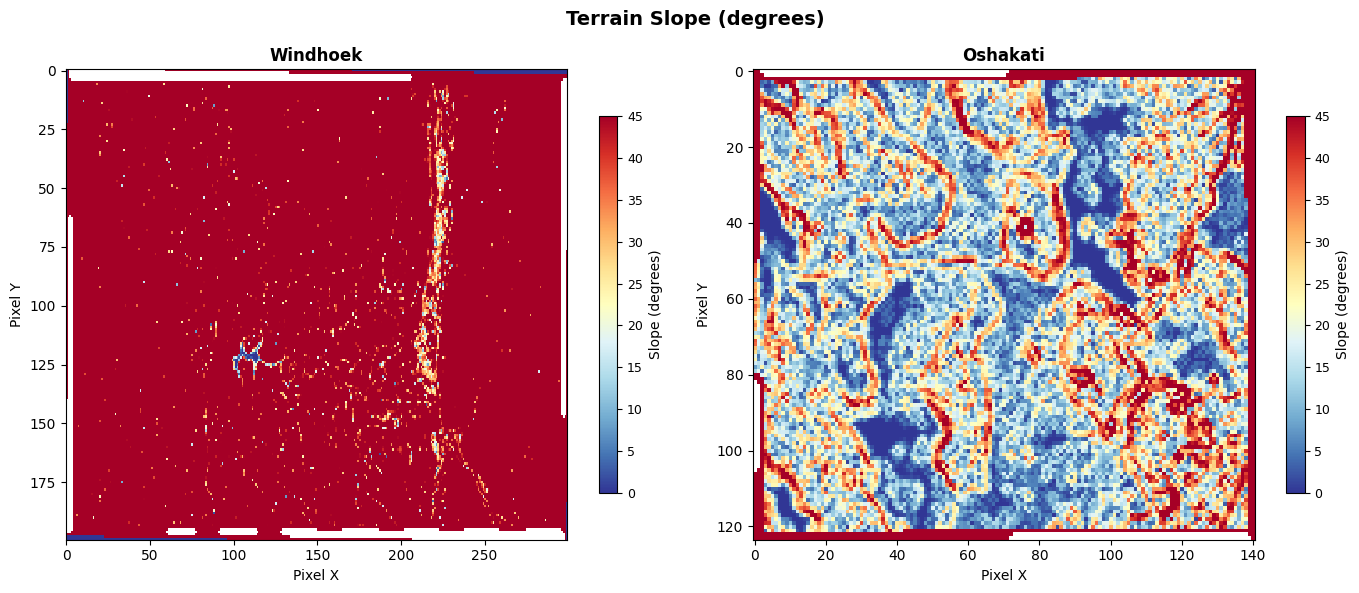


✓ Visualization 1 complete


In [73]:
# Visualization 1: Slope Maps
print("=" * 70)
print("VISUALIZATION 1: SLOPE MAPS")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Terrain Slope (degrees)', fontsize=14, fontweight='bold')

for idx, location_key in enumerate(STUDY_AREAS.keys()):
    ax = axes[idx]
    slope_path = path_windhoek_slope if location_key == 'windhoek' else path_oshakati_slope
    
    with rasterio.open(slope_path) as src:
        slope_data = src.read(1)
        slope_masked = np.ma.masked_equal(slope_data, NODATA_VALUE)
    
    im = ax.imshow(slope_masked, cmap='RdYlBu_r', aspect='auto', interpolation='nearest', vmin=0, vmax=45)
    ax.set_title(location_key.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Pixel X', fontsize=10)
    ax.set_ylabel('Pixel Y', fontsize=10)
    cbar = plt.colorbar(im, ax=ax, label='Slope (degrees)', shrink=0.8)
    cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
fig.savefig(RESULTS_FIGURES / '03_slope_maps.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 03_slope_maps.png")
plt.show()
print("\n✓ Visualization 1 complete")

VISUALIZATION 2: ASPECT CARDINAL DIRECTIONS
✓ Saved: 03_aspect_cardinal_directions.png
✓ Saved: 03_aspect_cardinal_directions.png


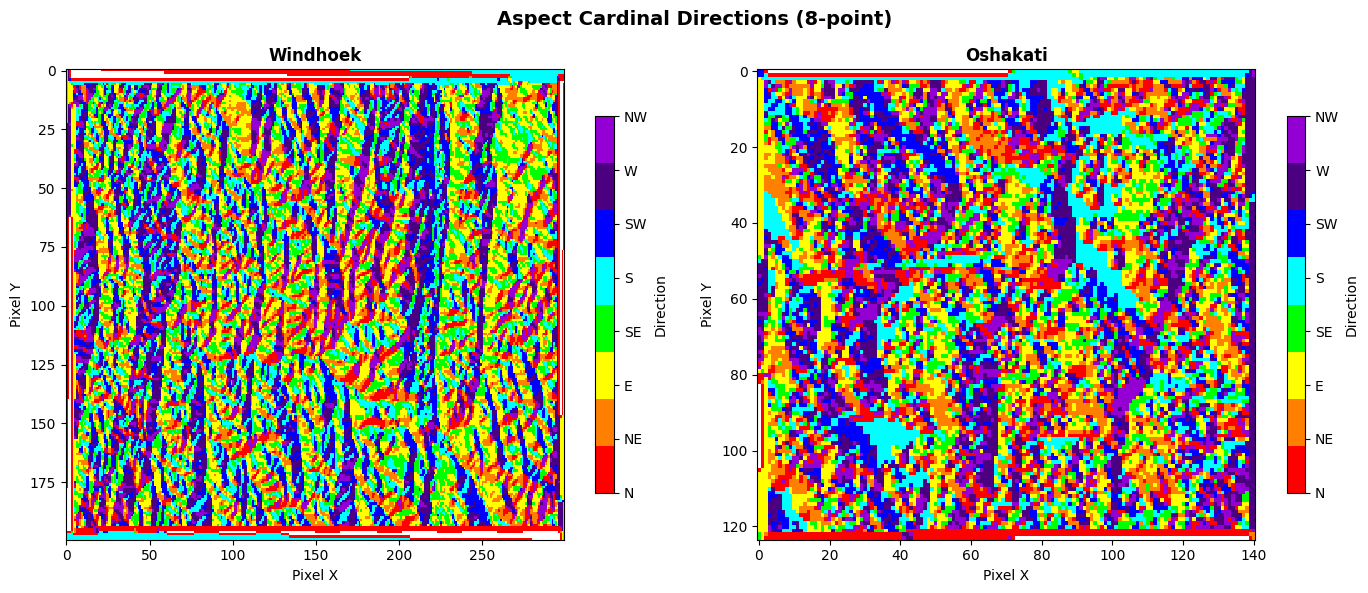


✓ Visualization 2 complete


In [74]:
# Visualization 2: Aspect Cardinal Directions
print("=" * 70)
print("VISUALIZATION 2: ASPECT CARDINAL DIRECTIONS")
print("=" * 70)

cardinal_names = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
cardinal_colors = ['#FF0000', '#FF7F00', '#FFFF00', '#00FF00', '#00FFFF', '#0000FF', '#4B0082', '#9400D3']
cardinal_cmap = ListedColormap(cardinal_colors)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Aspect Cardinal Directions (8-point)', fontsize=14, fontweight='bold')

for idx, location_key in enumerate(STUDY_AREAS.keys()):
    ax = axes[idx]
    cardinal_path = DATA_PROCESSED / ('windhoek_aspect_cardinal_30m.tif' if location_key == 'windhoek' else 'oshakati_aspect_cardinal_30m.tif')
    
    with rasterio.open(cardinal_path) as src:
        cardinal_data = src.read(1)
        cardinal_masked = np.ma.masked_equal(cardinal_data, NODATA_VALUE)
    
    im = ax.imshow(cardinal_masked, cmap=cardinal_cmap, aspect='auto', interpolation='nearest', vmin=0, vmax=7)
    ax.set_title(location_key.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Pixel X', fontsize=10)
    ax.set_ylabel('Pixel Y', fontsize=10)
    cbar = plt.colorbar(im, ax=ax, ticks=range(8), label='Direction', shrink=0.8)
    cbar.ax.set_yticklabels(cardinal_names)

plt.tight_layout()
fig.savefig(RESULTS_FIGURES / '03_aspect_cardinal_directions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 03_aspect_cardinal_directions.png")
plt.show()
print("\n✓ Visualization 2 complete")

VISUALIZATION 3: FLOW ACCUMULATION HEATMAPS (LOG SCALE)
✓ Saved: 03_flow_accumulation_heatmaps.png
✓ Saved: 03_flow_accumulation_heatmaps.png


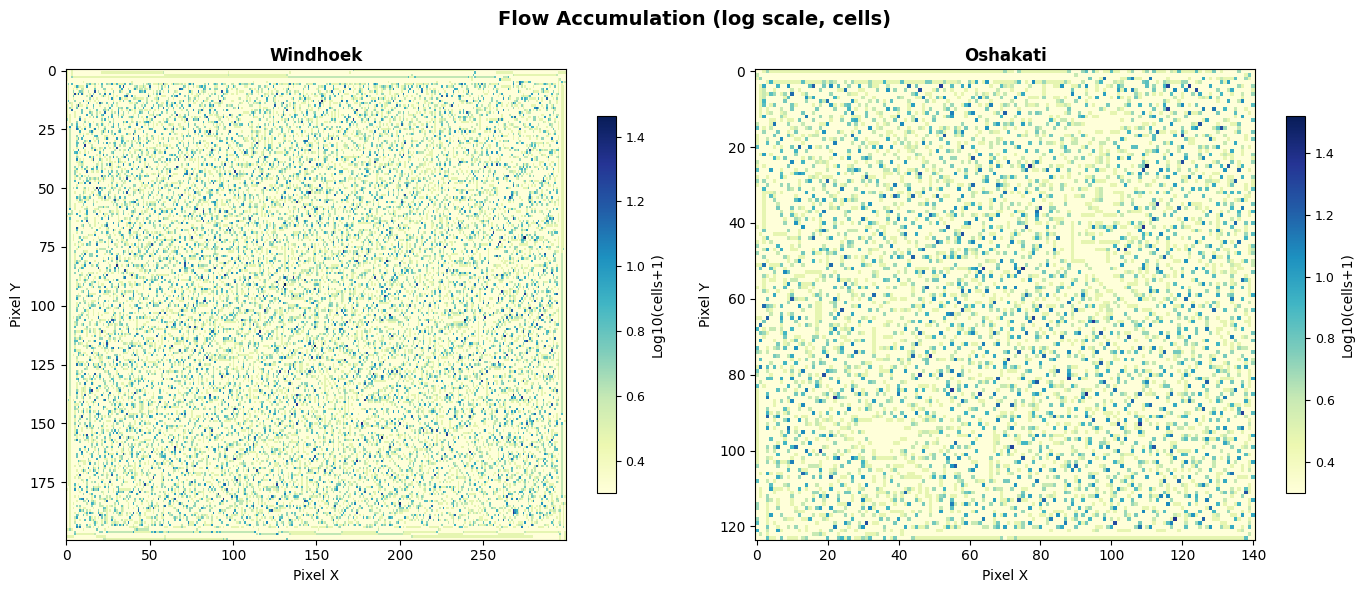


✓ Visualization 3 complete


In [75]:
# Visualization 3: Flow Accumulation Heatmaps
print("=" * 70)
print("VISUALIZATION 3: FLOW ACCUMULATION HEATMAPS (LOG SCALE)")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Flow Accumulation (log scale, cells)', fontsize=14, fontweight='bold')

for idx, location_key in enumerate(STUDY_AREAS.keys()):
    ax = axes[idx]
    flowaccum_path = path_windhoek_flowaccum if location_key == 'windhoek' else path_oshakati_flowaccum
    
    with rasterio.open(flowaccum_path) as src:
        flowaccum_data = src.read(1)
        flowaccum_log = np.log10(flowaccum_data + 1)
        flowaccum_log_masked = np.ma.masked_equal(flowaccum_log, 0)
    
    im = ax.imshow(flowaccum_log_masked, cmap='YlGnBu', aspect='auto', interpolation='nearest')
    ax.set_title(location_key.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Pixel X', fontsize=10)
    ax.set_ylabel('Pixel Y', fontsize=10)
    cbar = plt.colorbar(im, ax=ax, label='Log10(cells+1)', shrink=0.8)
    cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
fig.savefig(RESULTS_FIGURES / '03_flow_accumulation_heatmaps.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 03_flow_accumulation_heatmaps.png")
plt.show()
print("\n✓ Visualization 3 complete")

VISUALIZATION 4: FLOW ACCUMULATION THRESHOLD COMPARISONS

WINDHOEK:
  ✓ Saved: 03_threshold_comparison_windhoek.png
  ✓ Saved: 03_threshold_comparison_windhoek.png


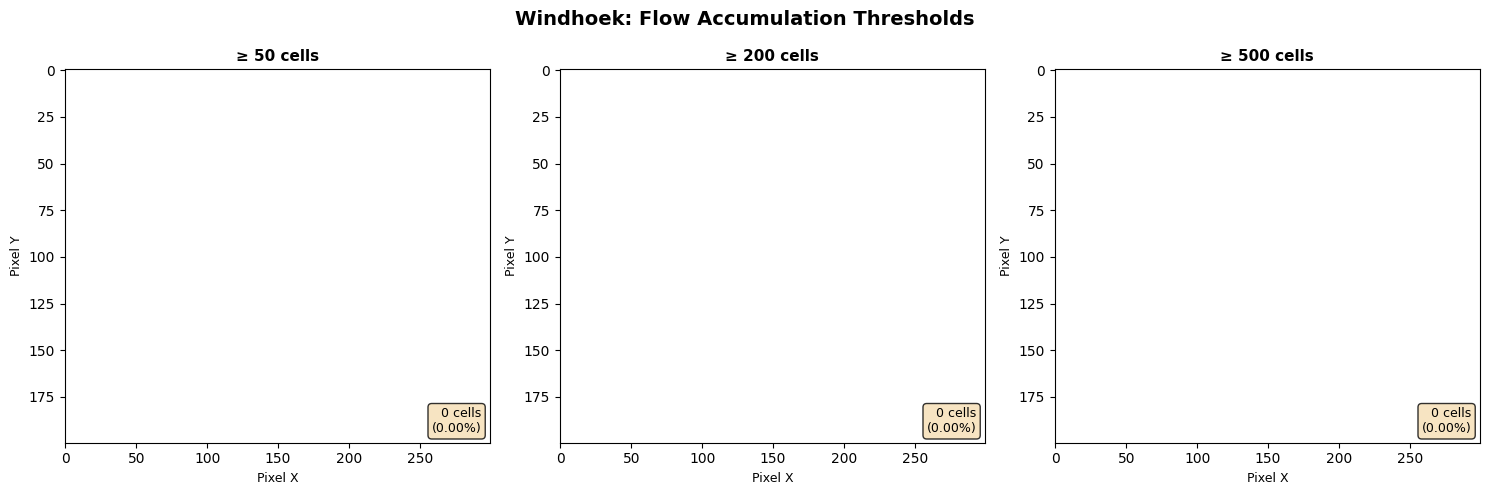


OSHAKATI:
  ✓ Saved: 03_threshold_comparison_oshakati.png
  ✓ Saved: 03_threshold_comparison_oshakati.png


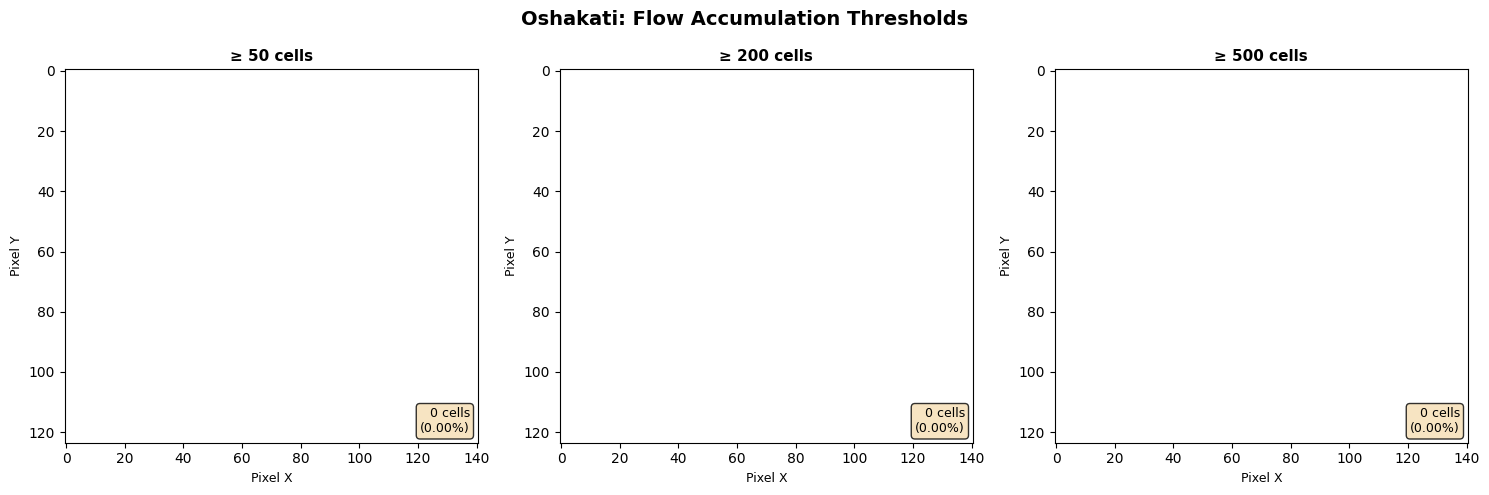


✓ Visualization 4 complete


In [76]:
# Visualization 4: Flow Accumulation Threshold Comparisons
print("=" * 70)
print("VISUALIZATION 4: FLOW ACCUMULATION THRESHOLD COMPARISONS")
print("=" * 70)

for location_key in STUDY_AREAS.keys():
    print(f"\n{location_key.upper()}:")
    flowaccum_path = path_windhoek_flowaccum if location_key == 'windhoek' else path_oshakati_flowaccum
    
    fig, axes = plt.subplots(1, len(FLOW_THRESHOLDS), figsize=(15, 5))
    fig.suptitle(f'{location_key.capitalize()}: Flow Accumulation Thresholds', fontsize=14, fontweight='bold')
    
    with rasterio.open(flowaccum_path) as src:
        flowaccum_data = src.read(1)
    
    for idx, threshold in enumerate(FLOW_THRESHOLDS):
        ax = axes[idx] if len(FLOW_THRESHOLDS) > 1 else axes
        classified = (flowaccum_data >= threshold).astype(np.uint8)
        classified_masked = np.ma.masked_equal(classified, 0)
        
        im = ax.imshow(classified_masked, cmap='Reds', aspect='auto', interpolation='nearest', vmin=0, vmax=1)
        ax.set_title(f'≥ {threshold} cells', fontsize=11, fontweight='bold')
        ax.set_xlabel('Pixel X', fontsize=9)
        ax.set_ylabel('Pixel Y', fontsize=9)
        
        cells_above = np.sum(classified == 1)
        pct_above = 100 * cells_above / classified.size
        ax.text(0.98, 0.02, f'{cells_above:,} cells\n({pct_above:.2f}%)', 
                transform=ax.transAxes, verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=9)
    
    plt.tight_layout()
    output_file = RESULTS_FIGURES / f'03_threshold_comparison_{location_key}.png'
    fig.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {output_file.name}")
    plt.show()

print("\n✓ Visualization 4 complete")

In [77]:
# Export Processing Log (JSON Metadata)
print("=" * 70)
print("EXPORT PROCESSING LOG & METADATA")
print("=" * 70)

processing_log = {
    'timestamp': datetime.now().isoformat(),
    'notebook': '03_Terrain_Derivatives_Hydrological_Analysis',
    'purpose': 'Compute terrain derivatives (slope, aspect, D8 flow) and classify flow accumulation thresholds',
    'parameters': {
        'target_crs': TARGET_CRS,
        'target_pixel_size': f'{TARGET_PIXEL_SIZE} m',
        'nodata_value': NODATA_VALUE,
        'flow_thresholds_cells': FLOW_THRESHOLDS,
        'slope_method': 'numpy.gradient (degrees)',
        'aspect_method': 'numpy.gradient (0-360°) + 8-point cardinal conversion',
        'flow_analysis': 'Whitebox D8 flow direction + accumulation (no depression filling)',
    },
    'input_dtm_metadata': {location_key: {'filename': m['filename'], 'crs': str(m['crs']), 'dimensions': f"{m['width']} x {m['height']} px", 'elevation_range': f"{m['stats']['min']:.2f} - {m['stats']['max']:.2f} m", 'mean_elevation': f"{m['stats']['mean']:.2f} m", 'nodata_percent': f"{m['stats']['nodata_percent']:.2f}%"} for location_key, m in dtm_metadata.items()},
    'slope_derivatives': slope_log,
    'flow_accumulation_statistics': flow_log,
    'threshold_classifications': threshold_log,
    'diagnostic_plots': {
        'slope_maps': 'results/figures/03_slope_maps.png',
        'aspect_cardinal_directions': 'results/figures/03_aspect_cardinal_directions.png',
        'flow_accumulation_heatmaps': 'results/figures/03_flow_accumulation_heatmaps.png',
        'threshold_comparisons_windhoek': 'results/figures/03_threshold_comparison_windhoek.png',
        'threshold_comparisons_oshakati': 'results/figures/03_threshold_comparison_oshakati.png',
    }
}

log_path = DATA_PROCESSED / 'processing_log_03.json'
with open(log_path, 'w') as f:
    json.dump(processing_log, f, indent=2)

print(f"✓ Processing log saved to: {log_path}")
print("\n" + "=" * 70)
print("PROCESSING SUMMARY")
print("=" * 70)
print(f"Timestamp: {processing_log['timestamp']}")
print(f"Flow accumulation thresholds: {FLOW_THRESHOLDS} cells")
print(f"\n✓ Notebook 03 execution complete!")

EXPORT PROCESSING LOG & METADATA
✓ Processing log saved to: /Users/jacobsmacbookpro/Namibia_python/data/processed/processing_log_03.json

PROCESSING SUMMARY
Timestamp: 2026-09-24T12:33:40.906329
Flow accumulation thresholds: [50, 200, 500] cells

✓ Notebook 03 execution complete!
✓ Processing log saved to: /Users/jacobsmacbookpro/Namibia_python/data/processed/processing_log_03.json

PROCESSING SUMMARY
Timestamp: 2026-09-24T12:33:40.906329
Flow accumulation thresholds: [50, 200, 500] cells

✓ Notebook 03 execution complete!


ERROR 1: PROJ: internal_proj_identify: /Users/jacobsmacbookpro/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/jacobsmacbookpro/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
